Example 3 - Supervised NLP Sentiment Analysis

This version uses **120 genuinely unique statements**: 40 Positive, 40 Negative, and 40 Neutral. It avoids artificial repetition and includes formal held-out evaluation plus testing on completely new statements.

**Workflow:** Labeled Text → Inspect → Clean → Stratified Split → TF-IDF → Dummy Baseline → Model Comparison → Evaluation → Confusion Matrix → Error Analysis → New Statements → Interactive Testing.


In [1]:
# 1. IMPORT LIBRARIES
# GUIDE: These libraries handle data, text features, ML models, and evaluation.
# GUIDE: random_state values used later make the experiment reproducible.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


In [2]:
# 2. CREATE 120 UNIQUE LABELED STATEMENTS
# GUIDE: Each statement appears only once; we do not inflate the dataset by repetition.
# GUIDE: The label is the known target that the supervised model will learn to predict.

positive = ['The instructor explained the lesson clearly and patiently.', 'The laboratory activity was useful and easy to follow.', 'I enjoyed the hands-on programming exercises.', 'The course materials helped me understand difficult concepts.', 'The professor provided helpful feedback on my assignment.', 'The online registration process was quick and convenient.', 'The library staff assisted me very well.', 'The new student portal is easy to navigate.', 'The computer laboratory has improved significantly.', 'The academic adviser gave me useful guidance.', 'The class discussions were engaging and informative.', 'The learning activities improved my understanding of the topic.', 'The support staff responded quickly to my concern.', 'The updated website makes information easier to find.', 'The workshop provided practical skills that I can use.', 'The instructor gave relevant examples during the lecture.', 'The system worked smoothly during my registration.', 'The campus WiFi connection was reliable during our class.', 'The consultation session helped me solve my problem.', 'The instructions for the activity were clear and complete.', 'The new laboratory computers performed very well.', 'The seminar was organized and informative.', 'The teacher encouraged us to participate in class.', 'The application is simple and convenient to use.', 'The enrollment staff handled my documents efficiently.', 'The research orientation answered many of my questions.', 'The recorded lectures were very helpful for reviewing lessons.', 'The classroom facilities were comfortable and functional.', 'The online learning resources were accessible and useful.', 'The instructor returned our graded work promptly.', 'The course gave me confidence in using machine learning tools.', 'The technical support team resolved my issue immediately.', 'The new dashboard presents information clearly.', 'The practical exercises were relevant to our thesis projects.', 'The university service exceeded my expectations.', 'The adviser carefully explained the requirements to me.', 'The training session was productive and well organized.', 'The mobile application made the process much easier.', 'The learning platform was stable throughout the activity.', 'The overall experience was satisfying and worthwhile.']
negative = ["The instructor's explanation was confusing and difficult to follow.", 'The laboratory activity was frustrating and poorly explained.', 'The system keeps crashing whenever I submit my requirements.', 'The campus WiFi is extremely slow and unreliable.', 'The enrollment process took too long to complete.', 'The registration portal repeatedly became unavailable.', 'The instructions for the assignment were unclear.', 'The computer laboratory has several outdated machines.', 'The support staff took too long to respond to my concern.', 'The website is difficult to navigate.', 'The application freezes whenever I open the report page.', 'The class activities were disorganized and confusing.', 'The learning materials did not explain the topic well.', 'The online system failed while I was uploading my file.', 'The queue during enrollment was unnecessarily long.', 'The computer became unresponsive during the laboratory exercise.', 'The adviser did not clearly explain the requirements.', 'The portal displayed several errors during registration.', 'The classroom equipment was not working properly.', 'The internet connection disconnected repeatedly during class.', 'The seminar was poorly organized and started very late.', 'The mobile application is difficult to use.', 'The instructions on the website are incomplete.', 'The service desk did not resolve my issue.', 'The course workload was overwhelming and poorly scheduled.', 'The system response time was extremely slow.', 'The laboratory did not have enough working computers.', 'The online learning platform was unavailable when I needed it.', 'The feedback on my assignment was too vague to be useful.', 'The registration procedure was unnecessarily complicated.', 'The application interface is confusing.', 'The uploaded documents disappeared from my account.', 'The technical support response was disappointing.', 'The classroom was uncomfortable and poorly maintained.', 'The training session did not address the important topics.', 'The system produced incorrect information in my record.', 'The enrollment instructions caused unnecessary confusion.', 'The course materials contained several unclear explanations.', 'The portal logged me out repeatedly while completing the form.', 'The overall experience was disappointing and stressful.']
neutral = ["The class begins at eight o'clock in the morning.", 'The seminar will be held in the computer laboratory.', 'The registration period starts on Monday.', 'The course has three laboratory activities this month.', 'The assignment must be submitted through the online portal.', "The library closes at six o'clock in the evening.", 'The system contains five main menu options.', 'The examination is scheduled for next week.', 'The instructor uploaded the presentation yesterday.', 'The enrollment office is located on the first floor.', 'The laboratory has thirty computer units.', 'The course includes lectures and laboratory sessions.', 'The student portal requires a university account.', 'The workshop is scheduled for two hours.', 'The class meets twice a week.', "The application displays the student's profile information.", 'The adviser will meet the students on Friday.', 'The registration form contains several required fields.', 'The report was uploaded to the learning platform.', 'The orientation program begins after lunch.', 'The computer laboratory is beside the faculty room.', 'The website provides a list of enrollment requirements.', 'The course uses Python for the programming exercises.', 'The system sends a notification after submission.', 'The library provides access to electronic resources.', 'The activity requires students to work in groups.', 'The portal shows the current enrollment status.', 'The instructor posted the laboratory instructions online.', 'The seminar has three scheduled speakers.', 'The application stores the submitted information.', 'The examination contains multiple-choice questions.', 'The course project is due at the end of the semester.', 'The registration office accepts documents during office hours.', 'The dashboard displays announcements and schedules.', 'The laboratory session lasts three hours.', 'The students will present their projects next week.', 'The system records the date and time of submission.', 'The university released the new academic calendar.', 'The consultation schedule is posted on the department page.', 'The survey contains questions about student experiences.']

df=pd.DataFrame({"Text":positive+negative+neutral,
                 "Sentiment":["Positive"]*40+["Negative"]*40+["Neutral"]*40})
df=df.sample(frac=1,random_state=42).reset_index(drop=True)
print("Positive:",len(positive),"Negative:",len(negative),"Neutral:",len(neutral))
print("Total:",len(df))
display(df.head(10))


Positive: 40 Negative: 40 Neutral: 40
Total: 120


,Text,Sentiment
0,The enrollment process took too long to complete.,Negative
1,The computer laboratory has several outdated m...,Negative
2,The professor provided helpful feedback on my ...,Positive
3,The computer became unresponsive during the la...,Negative
4,The recorded lectures were very helpful for re...,Positive
5,The course workload was overwhelming and poorl...,Negative
6,The classroom was uncomfortable and poorly mai...,Negative
7,The class discussions were engaging and inform...,Positive
8,The instructor's explanation was confusing and...,Negative
9,The instructor posted the laboratory instructi...,Neutral


In [3]:
# 3. INSPECT DATASET
# GUIDE: Always inspect missing values, duplicates, and class balance before modeling.
# GUIDE: Balanced classes make this teaching example easier to interpret.

print("Shape:",df.shape)
print("Missing values:\n",df.isnull().sum())
print("Duplicate statements:",df["Text"].duplicated().sum())
print("\nClass distribution:\n",df["Sentiment"].value_counts())
assert df["Text"].nunique()==120
print("\nAll 120 statements are unique.")


Shape: (120, 2)
Missing values:
 Text         0
Sentiment    0
dtype: int64
Duplicate statements: 0

Class distribution:
 Sentiment
Negative    40
Positive    40
Neutral     40
Name: count, dtype: int64

All 120 statements are unique.


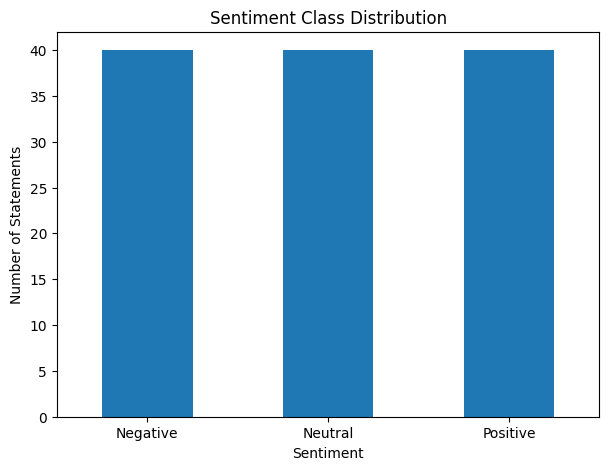

In [4]:
# 4. CLASS DISTRIBUTION
# GUIDE: The bar chart verifies how many examples belong to each sentiment class.

df["Sentiment"].value_counts().sort_index().plot(kind="bar",figsize=(7,5))
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment"); plt.ylabel("Number of Statements")
plt.xticks(rotation=0); plt.show()


## 5. Text Cleaning
For this introductory English example we lowercase, remove punctuation/non-letter characters, and normalize spaces. In real research, preprocessing must be justified for the language and task.


In [5]:
# 5. CLEAN TEXT
# GUIDE: Apply exactly the same cleaning procedure to training, test, and future text.
# GUIDE: Keep preprocessing simple here; real multilingual research may need different rules.

def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^a-z\s]"," ",text)
    return re.sub(r"\s+"," ",text).strip()
df["Clean_Text"]=df["Text"].apply(clean_text)
display(df[["Text","Clean_Text","Sentiment"]].head())


,Text,Clean_Text,Sentiment
0,The enrollment process took too long to complete.,the enrollment process took too long to complete,Negative
1,The computer laboratory has several outdated m...,the computer laboratory has several outdated m...,Negative
2,The professor provided helpful feedback on my ...,the professor provided helpful feedback on my ...,Positive
3,The computer became unresponsive during the la...,the computer became unresponsive during the la...,Negative
4,The recorded lectures were very helpful for re...,the recorded lectures were very helpful for re...,Positive


In [6]:
# 6. DEFINE X AND y
# GUIDE: X contains the input text; y contains the correct sentiment labels.

X=df["Clean_Text"]
y=df["Sentiment"]
print("Records:",len(X))
print("Classes:",sorted(y.unique()))


Records: 120
Classes: ['Negative', 'Neutral', 'Positive']


## 7. Stratified Train/Test Split
An **80:20 split** gives 96 training and 24 test statements. The test set remains unseen during training.


In [7]:
# 7. TRAIN/TEST SPLIT
# GUIDE: Training data teaches the model; test data evaluates it on unseen labeled examples.
# GUIDE: stratify=y preserves the class proportions in both subsets.

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y)
print("Training:",len(X_train))
print("Testing :",len(X_test))
print("\nTraining classes:\n",y_train.value_counts())
print("\nTesting classes:\n",y_test.value_counts())


Training: 96
Testing : 24

Training classes:
 Sentiment
Negative    32
Positive    32
Neutral     32
Name: count, dtype: int64

Testing classes:
 Sentiment
Positive    8
Neutral     8
Negative    8
Name: count, dtype: int64


## 8. TF-IDF
Fit TF-IDF **only on training text**. Transform, but never refit, on test or new statements. This prevents data leakage.


In [8]:
# 8. TF-IDF FEATURE EXTRACTION
# GUIDE: fit_transform learns the vocabulary ONLY from training text.
# GUIDE: transform applies that learned vocabulary to test data without leakage.

tfidf=TfidfVectorizer(stop_words="english",ngram_range=(1,2),min_df=1)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)
print("Training matrix:",X_train_tfidf.shape)
print("Test matrix:",X_test_tfidf.shape)
print("Vocabulary:",len(tfidf.get_feature_names_out()))


Training matrix: (96, 570)
Test matrix: (24, 570)
Vocabulary: 570


In [9]:
# 9. DUMMY BASELINE
# GUIDE: The Dummy Classifier is a naive reference point, not the intended final model.
# GUIDE: A useful learned model should normally outperform this baseline.

dummy=DummyClassifier(strategy="most_frequent",random_state=42)
dummy.fit(X_train_tfidf,y_train)
dummy_pred=dummy.predict(X_test_tfidf)
print("Dummy accuracy:",round(accuracy_score(y_test,dummy_pred),3))
print(classification_report(y_test,dummy_pred,zero_division=0))


Dummy accuracy: 0.333
              precision    recall  f1-score   support

    Negative       0.33      1.00      0.50         8
     Neutral       0.00      0.00      0.00         8
    Positive       0.00      0.00      0.00         8

    accuracy                           0.33        24
   macro avg       0.11      0.33      0.17        24
weighted avg       0.11      0.33      0.17        24



### How to interpret the baseline result

The Dummy Classifier provides a **minimum reference performance**. Because the teaching dataset contains equal numbers of Positive, Negative, and Neutral statements, a majority-class strategy has little information to exploit. The learned NLP models should be compared against this result.

**Student guide:** A model beating the dummy baseline does not automatically mean it is good enough. Examine the class-level metrics and errors as well.


In [10]:
# 10. TRAIN CANDIDATE MODELS
# GUIDE: Train several reasonable algorithms so performance can be compared.
# GUIDE: Do not assume a more complex model is automatically better.

models={
    "Logistic Regression":LogisticRegression(max_iter=1000,random_state=42),
    "Multinomial Naive Bayes":MultinomialNB(),
    "Linear SVM":LinearSVC(random_state=42)
}
predictions={}
for name,m in models.items():
    m.fit(X_train_tfidf,y_train)
    predictions[name]=m.predict(X_test_tfidf)
    print(name,"trained.")


Logistic Regression trained.
Multinomial Naive Bayes trained.
Linear SVM trained.


In [11]:
# 11. COMPARE MODELS
# GUIDE: Macro averages give each sentiment class equal importance.
# GUIDE: Compare several metrics rather than selecting a model from accuracy alone.

rows=[]
all_preds={"Dummy Classifier":dummy_pred,**predictions}
for name,pred in all_preds.items():
    rows.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision (Macro)":precision_score(y_test,pred,average="macro",zero_division=0),
        "Recall (Macro)":recall_score(y_test,pred,average="macro",zero_division=0),
        "F1 (Macro)":f1_score(y_test,pred,average="macro",zero_division=0)
    })
results=pd.DataFrame(rows).sort_values("F1 (Macro)",ascending=False)
display(results.round(3))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
3,Linear SVM,0.542,0.528,0.542,0.519
2,Multinomial Naive Bayes,0.542,0.512,0.542,0.515
1,Logistic Regression,0.458,0.444,0.458,0.442
0,Dummy Classifier,0.333,0.111,0.333,0.167


### How to interpret the model-comparison table

Read across each row rather than looking only at Accuracy.

- **Accuracy** — proportion of all test statements classified correctly.
- **Precision (Macro)** — average precision across Positive, Negative, and Neutral, giving each class equal weight.
- **Recall (Macro)** — average ability to retrieve the actual members of each class.
- **F1 (Macro)** — balances macro precision and macro recall.

A higher score is better for these metrics, but with this small synthetic dataset, minor score differences should **not** be treated as proof that one algorithm is universally superior.


## 12. Detailed Logistic Regression Example
Logistic Regression remains the teaching baseline for the detailed demonstration. In a thesis, model selection should be justified using appropriate validation, metrics, interpretability, computational constraints, and research requirements.


In [12]:
# 12. LOGISTIC REGRESSION METRICS
# GUIDE: Accuracy = overall proportion correct.
# GUIDE: Precision = how often predicted classes are correct; Recall = how many actual cases are found.
# GUIDE: F1 balances precision and recall.

model=models["Logistic Regression"]
y_pred=predictions["Logistic Regression"]
print("Accuracy :",round(accuracy_score(y_test,y_pred),3))
print("Precision:",round(precision_score(y_test,y_pred,average="macro"),3))
print("Recall   :",round(recall_score(y_test,y_pred,average="macro"),3))
print("F1       :",round(f1_score(y_test,y_pred,average="macro"),3))
print("\n",classification_report(y_test,y_pred,zero_division=0))


Accuracy : 0.458
Precision: 0.444
Recall   : 0.458
F1       : 0.442

               precision    recall  f1-score   support

    Negative       0.50      0.38      0.43         8
     Neutral       0.55      0.75      0.63         8
    Positive       0.29      0.25      0.27         8

    accuracy                           0.46        24
   macro avg       0.44      0.46      0.44        24
weighted avg       0.44      0.46      0.44        24



### How to interpret the classification report

The classification report shows **precision, recall, F1-score, and support for each sentiment class**.

For example, low **Negative recall** would mean some truly Negative statements are being classified as Neutral or Positive. Low **Positive precision** would mean that some statements predicted as Positive actually belong to other classes.

`support` is simply the number of actual test examples belonging to each class.


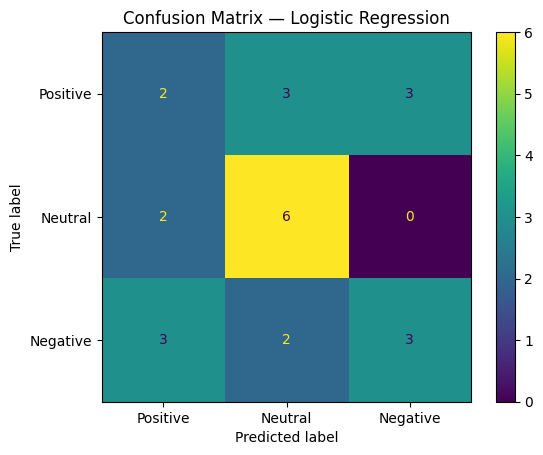

Rows = Actual; Columns = Predicted


In [13]:
# 13. CONFUSION MATRIX
# GUIDE: Read the matrix by ROW = actual class and COLUMN = predicted class.
# GUIDE: Diagonal cells are correct predictions; off-diagonal cells are errors.

labels=["Positive","Neutral","Negative"]
cm=confusion_matrix(y_test,y_pred,labels=labels)
ConfusionMatrixDisplay(cm,display_labels=labels).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()
print("Rows = Actual; Columns = Predicted")


### How to interpret the confusion matrix

The confusion matrix should be read as **Actual sentiment (rows) → Predicted sentiment (columns)**.

For this three-class problem:

| | Predicted Positive | Predicted Neutral | Predicted Negative |
|---|---:|---:|---:|
| **Actual Positive** | Correct Positive | Positive mistaken as Neutral | Positive mistaken as Negative |
| **Actual Neutral** | Neutral mistaken as Positive | Correct Neutral | Neutral mistaken as Negative |
| **Actual Negative** | Negative mistaken as Positive | Negative mistaken as Neutral | Correct Negative |

The **diagonal cells are correct predictions**. Any value outside the diagonal represents a misclassification.

**Example:** If the Actual Negative row contains `6, 2, 0` under Negative, Neutral, and Positive respectively (depending on displayed label order), the model correctly recognized 6 Negative statements and confused 2 with another sentiment. The actual numbers must be interpreted from the matrix produced when the notebook is run.


In [14]:
# 14. INSPECT TEST PREDICTIONS
# GUIDE: Inspect individual predictions instead of relying only on aggregate scores.

# Recover original statements through their retained indices.
test_results=pd.DataFrame({
    "Statement":df.loc[X_test.index,"Text"].values,
    "Actual":y_test.values,
    "Predicted":y_pred
})
test_results["Correct?"]=test_results["Actual"]==test_results["Predicted"]
display(test_results)


,Statement,Actual,Predicted,Correct?
0,The online registration process was quick and ...,Positive,Neutral,False
1,The application stores the submitted information.,Neutral,Positive,False
2,The system worked smoothly during my registrat...,Positive,Negative,False
3,The course uses Python for the programming exe...,Neutral,Positive,False
4,The laboratory activity was frustrating and po...,Negative,Positive,False
5,The practical exercises were relevant to our t...,Positive,Positive,True
6,The uploaded documents disappeared from my acc...,Negative,Neutral,False
7,The academic adviser gave me useful guidance.,Positive,Positive,True
8,The laboratory did not have enough working com...,Negative,Negative,True
9,The student portal requires a university account.,Neutral,Neutral,True


In [15]:
# 15. ERROR ANALYSIS
# GUIDE: Misclassified statements reveal vocabulary, ambiguity, or representation problems.
# GUIDE: Errors should guide the next experiment rather than simply being hidden.

errors=test_results[~test_results["Correct?"]]
print("Misclassified statements:",len(errors))
if len(errors):
    display(errors)
else:
    print("No errors occurred in this small held-out set.")
    print("This does not prove perfect generalization.")


Misclassified statements: 13


,Statement,Actual,Predicted,Correct?
0,The online registration process was quick and ...,Positive,Neutral,False
1,The application stores the submitted information.,Neutral,Positive,False
2,The system worked smoothly during my registrat...,Positive,Negative,False
3,The course uses Python for the programming exe...,Neutral,Positive,False
4,The laboratory activity was frustrating and po...,Negative,Positive,False
6,The uploaded documents disappeared from my acc...,Negative,Neutral,False
12,The system keeps crashing whenever I submit my...,Negative,Positive,False
13,The new student portal is easy to navigate.,Positive,Neutral,False
15,The research orientation answered many of my q...,Positive,Neutral,False
16,The course materials contained several unclear...,Negative,Positive,False


### How to interpret errors

Do not treat misclassifications simply as failures. Read each incorrect statement and ask **why** the model may have struggled.

Possible reasons include limited training examples, important words not represented strongly in training, ambiguous wording, negation, mixed sentiment, or TF-IDF's limited ability to represent context. These observations can justify the next model-improvement experiment.


## 16. Test Completely New Statements
These statements were **not in the 120-record dataset**. Expected labels are provided so students can check whether predictions agree with the intended sentiment. This practical generalization check complements—but does not replace—the formal test set.


In [16]:
# 16. NEW UNSEEN STATEMENTS
# GUIDE: These statements are separate from the original 120 records.
# GUIDE: This is an intuitive generalization check; it does NOT replace the formal test set.

new_statements=[
"The instructor made the difficult topic easy to understand.",
"I am very satisfied with the assistance I received.",
"The updated portal works smoothly and is easy to use.",
"The laboratory exercise was interesting and helpful.",
"The system is frustrating because it keeps producing errors.",
"I waited for hours and the problem was still not resolved.",
"The instructions are confusing and difficult to understand.",
"The internet connection is so slow that I cannot finish my work.",
"The meeting will begin at two o'clock this afternoon.",
"The application contains a page for student information.",
"The deadline for submission is on Friday.",
"The orientation will take place in the university auditorium."
]
expected=["Positive"]*4+["Negative"]*4+["Neutral"]*4
new_clean=[clean_text(x) for x in new_statements]
new_pred=model.predict(tfidf.transform(new_clean))
new_results=pd.DataFrame({
    "New Statement":new_statements,
    "Expected Sentiment":expected,
    "Predicted Sentiment":new_pred
})
new_results["Correct?"]=new_results["Expected Sentiment"]==new_results["Predicted Sentiment"]
display(new_results)
print("Correct:",new_results["Correct?"].sum(),"of",len(new_results))
print("Demonstration accuracy:",f'{new_results["Correct?"].mean():.1%}')


,New Statement,Expected Sentiment,Predicted Sentiment,Correct?
0,The instructor made the difficult topic easy t...,Positive,Positive,True
1,I am very satisfied with the assistance I rece...,Positive,Positive,True
2,The updated portal works smoothly and is easy ...,Positive,Positive,True
3,The laboratory exercise was interesting and he...,Positive,Negative,False
4,The system is frustrating because it keeps pro...,Negative,Negative,True
5,I waited for hours and the problem was still n...,Negative,Neutral,False
6,The instructions are confusing and difficult t...,Negative,Negative,True
7,The internet connection is so slow that I cann...,Negative,Negative,True
8,The meeting will begin at two o'clock this aft...,Neutral,Neutral,True
9,The application contains a page for student in...,Neutral,Neutral,True


Correct: 10 of 12
Demonstration accuracy: 83.3%


### How to interpret the unseen-statement test

`Correct? = True` means the prediction matches the **expected label supplied for this demonstration**. `False` identifies a useful case for discussion.

The displayed demonstration accuracy applies only to these manually prepared new examples. It should **not be reported as the formal model accuracy**; formal performance comes from the held-out test set.


## 17. Challenging Language
Mixed sentiment and negation are useful for showing students why sentiment analysis is not simply keyword matching.


In [17]:
# 17. CHALLENGING / AMBIGUOUS STATEMENTS
# GUIDE: Mixed sentiment and negation show why sentiment analysis is harder than keyword matching.

challenging=[
"The new interface looks better, but the system is still very slow.",
"The instructor is helpful, although the activities are difficult.",
"The service was not bad, but I expected a faster response.",
"The course is interesting, but there are too many requirements.",
"I do not dislike the new portal.",
"The application works, although the instructions could be clearer."
]
cp=model.predict(tfidf.transform([clean_text(x) for x in challenging]))
display(pd.DataFrame({"Statement":challenging,"Model Prediction":cp}))
print("Discuss: Do you agree with each prediction? Why?")


,Statement,Model Prediction
0,"The new interface looks better, but the system...",Negative
1,"The instructor is helpful, although the activi...",Positive
2,"The service was not bad, but I expected a fast...",Positive
3,"The course is interesting, but there are too m...",Neutral
4,I do not dislike the new portal.,Neutral
5,"The application works, although the instructio...",Negative


Discuss: Do you agree with each prediction? Why?


### Why challenging statements matter

A prediction for an ambiguous sentence does not necessarily have one indisputable 'correct' answer. Statements containing words such as *but*, *although*, or *not* may express contrast, negation, or mixed sentiment.

This section helps students distinguish **model prediction** from **human interpretation** and motivates more advanced contextual NLP methods.


In [18]:
# 18. INTERACTIVE STUDENT TEST
# GUIDE: Students can enter a completely new sentence and observe the trained model's prediction.

statement=input("Enter a new statement: ")
prediction=model.predict(tfidf.transform([clean_text(statement)]))[0]
print("\nStatement:",statement)
print("Predicted Sentiment:",prediction)


Enter a new statement: very good

Statement: very good
Predicted Sentiment: Positive


In [19]:
# 19. INSPECT HIGH-WEIGHTED LOGISTIC REGRESSION FEATURES
# GUIDE: High-weight features help explain what vocabulary influenced each class.
# GUIDE: These weights describe this trained model, not universal definitions of sentiment.

feature_names=np.array(tfidf.get_feature_names_out())
for i,class_name in enumerate(model.classes_):
    idx=model.coef_[i].argsort()[-10:][::-1]
    print("\n"+class_name.upper()+":")
    print(feature_names[idx])
# These are model-weight indicators, not universal definitions of sentiment.



NEGATIVE:
['did' 'confusing' 'poorly' 'repeatedly' 'long' 'difficult' 'unavailable'
 'unnecessarily' 'instructions' 'classroom']

NEUTRAL:
['contains' 'week' 'office' 'uploaded' 'clock' 'begins' 'displays'
 'examination' 'posted' 'provides']

POSITIVE:
['activity' 'staff' 'informative' 'improved' 'easier' 'explained'
 'helpful' 'provided' 'helped' 'organized']


# 20. Thesis Adaptation Guide
Students should document:
1. research problem and purpose;
2. unit of analysis;
3. text/data source;
4. definitions of Positive, Neutral, and Negative;
5. annotation procedure and annotators;
6. language(s), including Filipino/Bikol/Taglish where applicable;
7. preprocessing decisions;
8. feature representation;
9. baseline model;
10. candidate algorithms;
11. evaluation metrics;
12. error analysis;
13. genuinely unseen/generalization examples;
14. ethics and privacy;
15. language/gender/dialect bias considerations; and
16. limitations.

**Suggested thesis flow:** Dataset → Annotation → Cleaning → Stratified Split → TF-IDF Baseline → Model Comparison → Evaluation → Error Analysis → Improvement → Final Model → System Integration


# 21. Reflection Questions
1. Why should the same 30 statements not be repeated to create a larger dataset?
2. Why must TF-IDF be fitted only on training data?
3. Why establish a Dummy Classifier?
4. Why is accuracy alone insufficient?
5. What additional information does a confusion matrix provide?
6. Why test completely new statements after held-out evaluation?
7. Why do new manually entered statements not replace the formal test set?
8. Which statements were difficult for the model?
9. How could the dataset be improved?
10. What challenges arise with Filipino, Bikol, and Taglish sentiment?
11. When might BERT or another transformer be appropriate?
12. What ethical issues arise when analyzing real student feedback?


# Key Takeaways
- Sentiment analysis is supervised classification when labels are known.
- Use genuinely varied examples rather than artificial duplicates.
- Split before fitting TF-IDF.
- Establish a simple baseline and compare models.
- Use accuracy, precision, recall, F1, confusion matrices, and error analysis.
- Test genuinely unseen statements as a practical generalization demonstration.
- Formal held-out evaluation remains necessary.
- Real language includes ambiguity, negation, mixed sentiment, multilingual expressions, and context.
